# CO₂ Storage Heterogeneity Screening — Live Analysis of SPE11b

**Daniel Olagunju · Universiti Teknologi PETRONAS (UTP)**

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/todak2000/co2-heterogeneity-screening/HEAD?labpath=heterogeneity_screening.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/todak2000/co2-heterogeneity-screening/blob/main/heterogeneity_screening.ipynb)

This notebook reproduces, end-to-end and with **no hidden data or calibration constants**, the results of the companion paper *"Formation Heterogeneity in Analytical CO₂ Storage Screening: an Open-Source Implementation of Dykstra–Parsons, Shook–Mitchell and Kopp Corrections, Applied to the SPE11b Field-Scale Benchmark"*.

It runs in your browser — click **Binder** (no install) or **Open in Colab**. It only needs `numpy` and `matplotlib`.

**What it does, in one line:** implements three analytical heterogeneity corrections, derives the Dykstra–Parsons coefficient of the SPE11b benchmark from its published facies, and characterises the benchmark's CO₂ inventory from the official simulator time series — with the uncertainty made explicit.

**Headline results:** `V_DP = 0.66` (band 0.50–0.77) · residual trapping ≈ 0 at end of injection · 70–80% of injected CO₂ sits outside the reporting boxes at 50 yr.


In [1]:
import os, csv, glob, math, urllib.request
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Data access: use the files bundled in this repo (Binder / local clone), and fall
# back to downloading from GitHub raw (Colab).
GITHUB_RAW = "https://raw.githubusercontent.com/todak2000/co2-heterogeneity-screening/main/data/timeseries/"
def ensure_data():
    os.makedirs("data/timeseries", exist_ok=True)
    names = ["rice1_time_series.csv", "ctc-cne1_time_series.csv",
             "opm1_time_series.csv", "sintef1_time_series.csv"]
    for n in names:
        p = os.path.join("data", "timeseries", n)
        if not os.path.exists(p):
            urllib.request.urlretrieve(GITHUB_RAW + n, p)
            print("downloaded", n)

ensure_data()

# --- analytical heterogeneity corrections (Eqs 1-6 of the paper) ---
MD = 9.869233e-16  # m^2 per millidarcy

def shook_mitchell_E_s(V, pvi, phi):
    # Empirical screening adaptation of Shook & Mitchell (2009): the exponential
    # E_s = 1 - exp(-3*PVI*FQI) is a conventional surrogate fitted to their
    # breakthrough behaviour, not an equation derived in their paper (manuscript Sec 2.2).
    V = max(0.0, min(0.85, V)); phi = max(0.01, min(0.5, phi))
    if V < 1e-10:
        return max(0.0, min(1.0, 1.0 - math.exp(-3.0 * pvi / phi)))
    FQI = math.sqrt(1.0 / (1.0 - V)) * (1.0 - V) / phi
    return max(0.0, min(1.0, 1.0 - math.exp(-3.0 * pvi * FQI)))

def kopp_E_c(V, pvi, phi, ntg, kh_kv, M):
    E_geo = max(0.01, min(1.0, ntg)) / math.sqrt(kh_kv)
    E_s = shook_mitchell_E_s(V, pvi, phi)
    E_d = 1.0 / math.sqrt(max(1.0, M))
    return max(0.01, min(1.0, E_geo * E_s * E_d))


## 1. SPE11b facies and the Dykstra–Parsons coefficient

The SPE11b benchmark (Nordbotten et al. 2024) is a field-scale CO₂ storage cross-section with seven facies. The benchmark **does not define a Dykstra–Parsons coefficient**, so we derive it from the published facies table (spec Table 4): the five reservoir sands only, via the log-normal relation `V_DP = 1 - exp(-sigma_ln)`.

In [2]:
# Facies: (name, k [m^2], porosity, role)
facies = [
    ("1 seal",        1.0e-16, 0.10, "seal"),
    ("2 sand",        1.0e-13, 0.20, "reservoir"),
    ("3 sand",        2.0e-13, 0.20, "reservoir"),
    ("4 sand",        5.0e-13, 0.20, "reservoir"),
    ("5 sand",        1.0e-12, 0.25, "reservoir"),
    ("6 sand",        2.0e-12, 0.35, "reservoir"),
    ("7 impermeable", 0.0,     0.00, "impermeable"),
]
print(f"{'facies':14s}{'k [mD]':>10s}{'phi':>7s}")
for name, k, phi, role in facies:
    print(f"{name:14s}{k/MD:10.2f}{phi:7.2f}")

res = [k/MD for _, k, _, r in facies if r == "reservoir"]
ln = [math.log(k) for k in res]
n = len(ln)
sigma_ln = math.sqrt(sum((x - sum(ln)/n)**2 for x in ln) / n)
V_DP = 1 - math.exp(-sigma_ln)
se = sigma_ln / math.sqrt(2*(n-1))          # std error of sample log-sd
V_lo = 1 - math.exp(-(sigma_ln - se))       # lower bound of 1-sigma band
V_hi = 1 - math.exp(-(sigma_ln + se))       # upper bound of 1-sigma band
print(f"\nreservoir sands [mD] : {[round(k,1) for k in res]}")
print(f"arithmetic mean        : {sum(res)/n:.1f} mD")
print(f"sigma_ln               : {sigma_ln:.4f}")
print(f"V_DP                   : {V_DP:.4f}  (1 sigma band {V_lo:.2f}-{V_hi:.2f})")

facies            k [mD]    phi
1 seal              0.10   0.10
2 sand            101.32   0.20
3 sand            202.65   0.20
4 sand            506.62   0.20
5 sand           1013.25   0.25
6 sand           2026.50   0.35
7 impermeable       0.00   0.00

reservoir sands [mD] : [101.3, 202.6, 506.6, 1013.2, 2026.5]
arithmetic mean        : 770.1 mD
sigma_ln               : 1.0763
V_DP                   : 0.6592  (1 sigma band 0.50-0.77)


## 2. Analytical sweep and storage efficiency

Shook–Mitchell sweep efficiency `E_s = 1 - exp(-3·PVI·FQI)` and the Kopp et al. capacity factor `E_c = E_geo·E_s·E_d`. Heterogeneity reduces both.

In [3]:
pvi, phi = 0.05, 0.20
print("Shook-Mitchell sweep efficiency E_s:")
print(f"{'phi':>5s}{'PVI':>7s}{'E_s(V=0)':>10s}{'E_s(V=0.66)':>13s}{'ratio':>8s}")
for phi_ in (0.20, 0.25):
    for pvi_ in (0.02, 0.05, 0.10):
        e0 = shook_mitchell_E_s(0.0, pvi_, phi_)
        ev = shook_mitchell_E_s(V_DP, pvi_, phi_)
        print(f"{phi_:5.2f}{pvi_:7.2f}{e0:10.3f}{ev:13.3f}{ev/e0:8.3f}")

# Kopp capacity factor (documented assumptions: NTG=0.85, kh/kv=10, M=10)
Ec0 = kopp_E_c(0.0, pvi, phi, 0.85, 10.0, 10.0)
EcV = kopp_E_c(V_DP, pvi, phi, 0.85, 10.0, 10.0)
print(f"\nKopp capacity factor E_c @ PVI=0.05, phi=0.20:  "
      f"E_c(V=0)={Ec0:.3f}  E_c(V=0.66)={EcV:.3f}")

Shook-Mitchell sweep efficiency E_s:
  phi    PVI  E_s(V=0)  E_s(V=0.66)   ratio
 0.20   0.02     0.259        0.161   0.620
 0.20   0.05     0.528        0.355   0.672
 0.20   0.10     0.777        0.583   0.751
 0.25   0.02     0.213        0.131   0.613
 0.25   0.05     0.451        0.296   0.655
 0.25   0.10     0.699        0.504   0.721

Kopp capacity factor E_c @ PVI=0.05, phi=0.20:  E_c(V=0)=0.045  E_c(V=0.66)=0.030


## 3. Benchmark CO₂ inventory (the honest benchmark result)

The benchmark reports CO₂ **by compartment** (mobile / immobile / dissolved / seal) per box, in a time series. We compute each compartment as a fraction of the total injected CO₂ (`0.035 kg/(s·m)` over 50 yr from Well 1 and 25 yr from Well 2 = **8.2782×10⁷ kg/m**).

In [4]:
TOTAL = 0.035 * (50*365*86400) + 0.035 * (25*365*86400)   # kg/m
T_TARGET = {50:1.5768e9, 100:3.1536e9, 200:6.3072e9, 500:1.5768e10, 1000:3.1536e10}

def load_ts(path):
    out=[]
    with open(path) as fh:
        for r in csv.reader(fh):
            if not r or r[0].startswith("#"): continue
            try: out.append([float(x) for x in r])
            except (ValueError, IndexError): continue
    return out

def at_year(rows, t): return min(rows, key=lambda r: abs(r[0]-t))

def compartments(row):
    return dict(mobile=row[3]+row[7], immobile=row[4]+row[8],
                dissolved=row[5]+row[9], seal_total=row[12], boundary=row[13])

sims = {}
for p in glob.glob("data/timeseries/*_time_series.csv"):
    name = os.path.basename(p).replace("_time_series.csv","")
    sims[name] = load_ts(p)

print(f"Total injected CO2 = {TOTAL:.4e} kg/m")
print(f"{'sim':10s}{'yr':>5s}{'mobile':>9s}{'immobile':>10s}{'dissolved':>11s}{'seal':>8s}{'box budget':>12s}")
print("-"*65)
for name in sorted(sims):
    for yr in (50, 1000):
        c = compartments(at_year(sims[name], T_TARGET[yr]))
        m=c['mobile']/TOTAL*100; i=c['immobile']/TOTAL*100
        d=c['dissolved']/TOTAL*100; s=c['seal_total']/TOTAL*100
        reported = (c['mobile']+c['immobile']+c['dissolved']+c['seal_total']+c['boundary'])
        print(f"{name:10s}{yr:>5d}{m:9.1f}{i:10.2f}{d:11.1f}{s:8.1f}{reported/TOTAL*100:12.1f}")

Total injected CO2 = 8.2782e+07 kg/m
sim          yr   mobile  immobile  dissolved    seal  box budget
-----------------------------------------------------------------
ctc-cne1     50     25.9      4.39        1.8     0.3        32.4
ctc-cne1   1000     33.9      5.51       12.2     0.3        51.9
opm1         50     27.5      0.06        1.7     0.4        29.6
opm1       1000     44.3      0.13        8.9     0.8        54.2
rice1        50     16.5      0.06        1.9     2.3        20.8
rice1      1000     10.0      1.36       22.7    23.0        57.1
sintef1      50     27.5      0.04        1.6     0.1        29.3
sintef1    1000     43.9      0.26        8.6     0.2        53.0


## 4. Figures

The three figures of the paper, rendered inline.

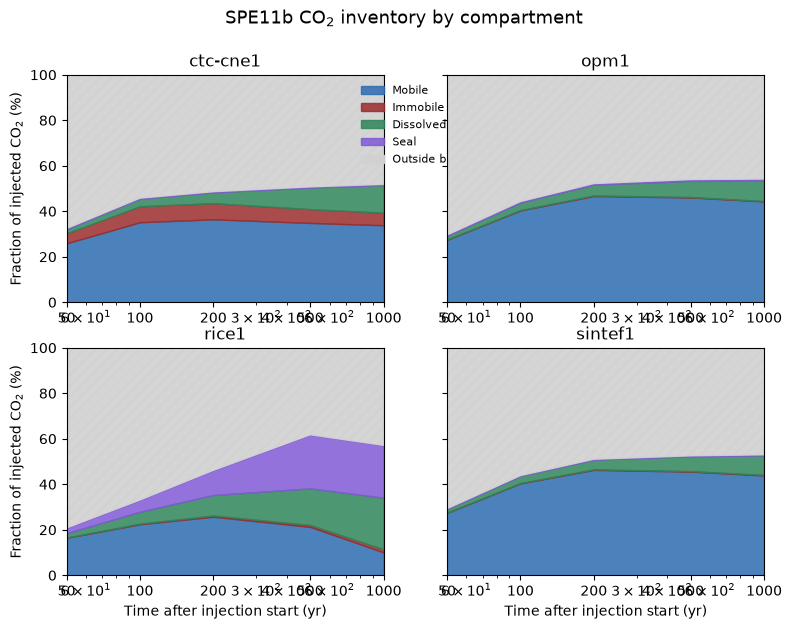

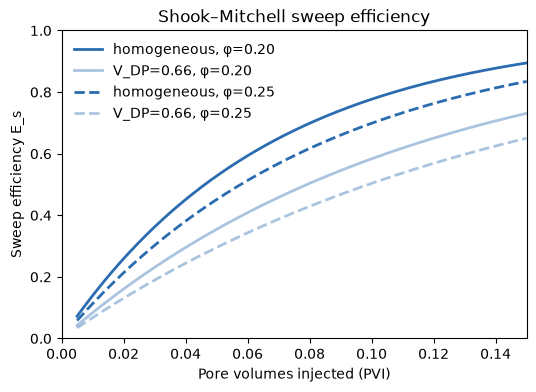

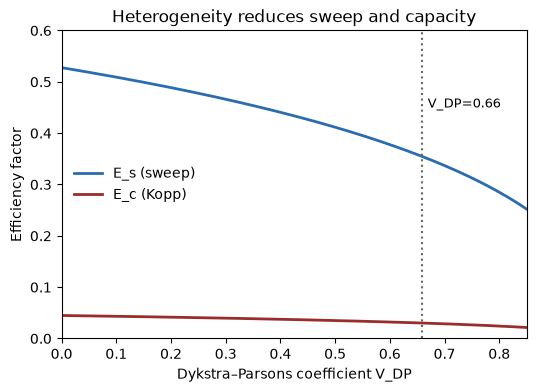

In [5]:
# --- Figure 1: compartment inventory vs time (4 simulators) ---
order = sorted(sims)
cats = ["mobile", "immobile", "dissolved", "seal_total"]
labels = ["Mobile", "Immobile (residual)", "Dissolved", "Seal"]
colors = ["#2b6cb0", "#9b2c2c", "#2f855a", "#805ad5"]
TIMES = [50, 100, 200, 500, 1000]
fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), sharey=True)
for ax, name in zip(axes.ravel(), order):
    c = {yr: compartments(at_year(sims[name], T_TARGET[yr])) for yr in TIMES}
    bottom = np.zeros(len(TIMES))
    for k, lab, col in zip(cats, labels, colors):
        v = np.array([c[yr][k]/TOTAL*100 for yr in TIMES])
        ax.fill_between(TIMES, bottom, bottom+v, label=lab, color=col, alpha=0.85)
        bottom += v
    ax.fill_between(TIMES, bottom, 100, color="0.82", alpha=0.9, hatch="///",
                    label="Outside boxes A/B")
    ax.set_title(name); ax.set_xscale("log"); ax.set_xlim(50,1000)
    ax.set_xticks(TIMES); ax.set_xticklabels([str(t) for t in TIMES])
    ax.set_ylim(0,100)
for a in axes[:,0]: a.set_ylabel("Fraction of injected CO$_2$ (%)")
for a in axes[1,:]: a.set_xlabel("Time after injection start (yr)")
axes.ravel()[0].legend(loc="upper center", bbox_to_anchor=(1.15,1.0), frameon=False, fontsize=8)
fig.suptitle("SPE11b CO$_2$ inventory by compartment", fontsize=13)
plt.show()

# --- Figure 2: E_s vs PVI ---
pvigrid = np.linspace(0.005, 0.15, 200)
fig, ax = plt.subplots(figsize=(6,4))
for phi_, ls in [(0.20, "-"), (0.25, "--")]:
    ax.plot(pvigrid, [shook_mitchell_E_s(0.0, p, phi_) for p in pvigrid],
            ls=ls, color="#2b6cb0", lw=2, label=f"homogeneous, φ={phi_:.2f}")
    ax.plot(pvigrid, [shook_mitchell_E_s(V_DP, p, phi_) for p in pvigrid],
            ls=ls, color="#2b6cb0", lw=2, alpha=0.4, label=f"V_DP={V_DP:.2f}, φ={phi_:.2f}")
ax.set_xlabel("Pore volumes injected (PVI)"); ax.set_ylabel("Sweep efficiency E_s")
ax.set_xlim(0,0.15); ax.set_ylim(0,1); ax.legend(frameon=False)
ax.set_title("Shook–Mitchell sweep efficiency")
plt.show()

# --- Figure 3: sensitivity to V_DP ---
Vgrid = np.linspace(0, 0.85, 200)
es = [shook_mitchell_E_s(v, 0.05, 0.20) for v in Vgrid]
ec = [kopp_E_c(v, 0.05, 0.20, 0.85, 10.0, 10.0) for v in Vgrid]
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(Vgrid, es, lw=2, color="#2b6cb0", label="E_s (sweep)")
ax.plot(Vgrid, ec, lw=2, color="#9b2c2c", label="E_c (Kopp)")
ax.axvline(V_DP, ls=":", color="0.4"); ax.text(V_DP+0.01, 0.45, f"V_DP={V_DP:.2f}", fontsize=9)
ax.set_xlabel("Dykstra–Parsons coefficient V_DP")
ax.set_ylabel("Efficiency factor"); ax.set_xlim(0,0.85); ax.set_ylim(0,0.6)
ax.legend(frameon=False)
ax.set_title("Heterogeneity reduces sweep and capacity")
plt.show()

## 5. Uncertainty quantification (no hidden assumptions)

Two sources of uncertainty are quantified directly from the data.

In [6]:
# (a) Model uncertainty = the inter-simulator spread (the benchmark IS an ensemble)
print("Model uncertainty (4-simulator ensemble):")
for yr in (50, 1000):
    mob = [compartments(at_year(sims[n], T_TARGET[yr]))['mobile']/TOTAL*100 for n in sims]
    diss = [compartments(at_year(sims[n], T_TARGET[yr]))['dissolved']/TOTAL*100 for n in sims]
    seal = [compartments(at_year(sims[n], T_TARGET[yr]))['seal_total']/TOTAL*100 for n in sims]
    print(f"  t={yr:4d} yr: mobile {min(mob):.1f}-{max(mob):.1f}%, "
          f"dissolved {min(diss):.1f}-{max(diss):.1f}%, seal {min(seal):.1f}-{max(seal):.1f}%")

# (b) Parameter uncertainty = V_DP sampling band + PVI, propagated through E_s
print(f"\nParameter uncertainty:")
print(f"  V_DP 1-sigma band: {V_lo:.2f} - {V_hi:.2f}")
for V in (0.0, V_lo, V_DP, V_hi):
    print(f"    E_s(V={V:.2f}) @ PVI=0.05, phi=0.20 = {shook_mitchell_E_s(V, 0.05, 0.20):.3f}")
print("  PVI uncertainty (0.02-0.10) at V_DP=0.66:",
      f"E_s in [{shook_mitchell_E_s(V_DP,0.02,0.20):.2f}, {shook_mitchell_E_s(V_DP,0.10,0.20):.2f}]")

Model uncertainty (4-simulator ensemble):
  t=  50 yr: mobile 16.5-27.5%, dissolved 1.6-1.9%, seal 0.1-2.3%
  t=1000 yr: mobile 10.0-44.3%, dissolved 8.6-22.7%, seal 0.2-23.0%

Parameter uncertainty:
  V_DP 1-sigma band: 0.50 - 0.77
    E_s(V=0.00) @ PVI=0.05, phi=0.20 = 0.528
    E_s(V=0.50) @ PVI=0.05, phi=0.20 = 0.411
    E_s(V=0.66) @ PVI=0.05, phi=0.20 = 0.355
    E_s(V=0.77) @ PVI=0.05, phi=0.20 = 0.304
  PVI uncertainty (0.02-0.10) at V_DP=0.66: E_s in [0.16, 0.58]


## Takeaway

* The three alterations of heterogeneity on screening are **quantifiable** and the corrections are simple and cheap — but they are *heuristics*, not validated predictions.
* Their "sweep efficiency" and the benchmark's compartment inventory are **different physical quantities**; a meaningful quantitative comparison needs a benchmark-consistent metric that SPE11b does not (yet) define.
* For this field-scale benchmark, **residual trapping is negligible** and dissolution + structural trapping carry long-term security — a result worth internalising when calibrating screening tools.
* Everything above is reproducible: rerun any cell, or clone the repo and run `scripts/` alongside this notebook.

**Data & code:** bundled in this repo (`data/timeseries/`, `scripts/`, `manuscript.md`). SPE11b data © the 11th SPE Comparative Solution Project (Nordbotten et al. 2024, https://spe.org/csp/spe11).